# 🎬 Movie Review Sentiment Analysis
### An Intelligent NLP-Driven Framework for Movie Review Classification
**Bangalore Institute of Technology — CSE (Data Science)**

---
### Models Compared:
1. **LSTM** — Baseline recurrent neural network
2. **DistilBERT** — Lightweight transformer (fine-tuned)
3. **BERT** — Full bidirectional transformer (fine-tuned)
4. **Hybrid: DistilBERT + TF-IDF** — Novel combined model (proposed)

**Dataset:** IMDB Large Movie Review Dataset (50,000 reviews)

> ⚠️ **Runtime:** Set to GPU (Runtime → Change Runtime Type → T4 GPU) before running

## 📦 Section 1: Install Dependencies

In [ ]:
# Install all required packages cleanly
!pip install -q transformers==4.40.0 datasets torch torchvision scikit-learn
!pip install -q matplotlib seaborn tqdm
print('✅ All packages installed')

# ── Mount Google Drive for auto-saving predictions ──
from google.colab import drive
drive.mount('/content/drive')
import os, pickle
SAVE_DIR = '/content/drive/MyDrive/NLP_MovieReview_Results/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Drive mounted — saving to: {SAVE_DIR}')

# ── Show what's already saved from previous sessions ──
print('\n📂 Already saved from previous sessions:')
for fname in ['lstm.pkl', 'distilbert.pkl', 'bert.pkl', 'hybrid.pkl', 'test_labels.pkl']:
    status = '✅ Done' if os.path.exists(SAVE_DIR + fname) else '❌ Not yet'
    print(f'   {fname}: {status}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 132.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ All packages installed
Mounted at /content/drive
✅ Drive mounted — saving to: /content/drive/MyDrive/NLP_MovieReview_Results/

📂 Already saved from previous sessions:
   lstm.pkl: ✅ Done
   distilbert.pkl: ✅ Done
   bert.pkl: ✅ Done
   hybrid.pkl: ✅ Done
   test_labels.pkl: ✅ Done


## 📚 Section 2: Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Transformers
from transformers import (
    AutoTokenizer, AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

# HuggingFace Datasets
from datasets import load_dataset
from tqdm.auto import tqdm

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ All imports successful')
print(f'🖥️  Using device: {DEVICE}')

✅ All imports successful
🖥️  Using device: cuda


## 📂 Section 3: Load & Prepare IMDB Dataset

In [ ]:
# Load IMDB dataset from HuggingFace
print('Loading IMDB dataset...')
dataset = load_dataset('imdb')

# Full dataset for paper results
N_TRAIN = 25000
N_TEST  = 25000

import random

# Shuffle before slicing to ensure both classes are present
train_data = list(zip(dataset['train']['text'], dataset['train']['label']))
test_data  = list(zip(dataset['test']['text'],  dataset['test']['label']))

random.seed(42)
random.shuffle(train_data)
random.shuffle(test_data)

train_texts,  train_labels = zip(*train_data[:N_TRAIN])
test_texts,   test_labels  = zip(*test_data[:N_TEST])

train_texts  = list(train_texts)
test_texts   = list(test_texts)
train_labels = list(train_labels)
test_labels  = list(test_labels)

print(f'✅ Dataset loaded')
print(f'   Train samples : {len(train_texts)}')
print(f'   Test  samples : {len(test_texts)}')
print(f'   Label balance : {sum(train_labels)} positive / {len(train_labels)-sum(train_labels)} negative')

# ── Auto-save test labels immediately ──
pickle.dump(test_labels, open(SAVE_DIR + 'test_labels.pkl', 'wb'))
print('✅ test_labels.pkl saved to Drive')


Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Dataset loaded
   Train samples : 25000
   Test  samples : 25000
   Label balance : 12500 positive / 12500 negative
✅ test_labels.pkl saved to Drive


## 🔧 Section 4: Text Preprocessing (for LSTM)
Tokenization, stopword removal, vocabulary building

In [ ]:
import re
from collections import Counter

# --- Basic text cleaning ---
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    text = text.lower().strip()              # lowercase
    return text

# Simple stopwords (no NLTK dependency)
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it',
    'its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were',
    'be','been','being','have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through',
    'during','before','after','to','from','up','down','in','out','on','off',
    'over','under','again','further','then','once','here','there','when',
    'where','why','how','all','both','each','few','more','most','other',
    'some','such','no','nor','not','only','own','same','so','than','too',
    'very','s','t','can','will','just','don','should','now','d','ll','m',
    'o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn',
    'weren','won','wouldn'
])

def tokenize(text):
    tokens = clean_text(text).split()
    return [t for t in tokens if t not in STOPWORDS]

# Build vocabulary from training data
print('Building vocabulary...')
all_tokens = [token for text in train_texts for token in tokenize(text)]
vocab_counter = Counter(all_tokens)
VOCAB_SIZE = 10000
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(text, max_len=200):
    tokens = tokenize(text)[:max_len]
    ids = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    # Pad to max_len
    ids += [0] * (max_len - len(ids))
    return ids

MAX_LEN = 200
X_train_lstm = np.array([encode(t, MAX_LEN) for t in train_texts])
X_test_lstm  = np.array([encode(t, MAX_LEN) for t in test_texts])
y_train      = np.array(train_labels)
y_test       = np.array(test_labels)

print(f'✅ Preprocessing complete')
print(f'   Vocabulary size : {len(vocab)}')
print(f'   Train shape     : {X_train_lstm.shape}')
print(f'   Test  shape     : {X_test_lstm.shape}')

Building vocabulary...
✅ Preprocessing complete
   Vocabulary size : 10000
   Train shape     : (25000, 200)
   Test  shape     : (25000, 200)


## 🧠 Section 5: Model 1 — LSTM
Baseline recurrent neural network with embedding layer

In [ ]:
# --- LSTM Dataset ---
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_lstm = DataLoader(
    IMDBDataset(X_train_lstm, y_train), batch_size=64, shuffle=True
)
test_loader_lstm  = DataLoader(
    IMDBDataset(X_test_lstm, y_test),  batch_size=64, shuffle=False
)

# --- LSTM Model Architecture ---
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

# --- Training helpers ---
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += ((torch.sigmoid(preds) > 0.5) == y_batch.bool()).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_preds = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item()
            binary = (torch.sigmoid(preds) > 0.5).long()
            correct += (binary == y_batch.long()).sum().item()
            all_preds.extend(binary.cpu().numpy())
    return total_loss / len(loader), correct / len(loader.dataset), all_preds

# Instantiate
lstm_model = LSTMSentiment(vocab_size=len(vocab)).to(DEVICE)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion  = nn.BCEWithLogitsLoss()

LSTM_EPOCHS = 5
lstm_train_acc_history = []
lstm_val_acc_history   = []

print('Training LSTM...')
for epoch in range(LSTM_EPOCHS):
    train_loss, train_acc = train_epoch(lstm_model, train_loader_lstm, optimizer, criterion)
    val_loss, val_acc, _  = eval_epoch(lstm_model, test_loader_lstm, criterion)
    lstm_train_acc_history.append(train_acc)
    lstm_val_acc_history.append(val_acc)
    print(f'  Epoch {epoch+1}/{LSTM_EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

_, lstm_accuracy, lstm_preds = eval_epoch(lstm_model, test_loader_lstm, criterion)
print(f'\n✅ LSTM Test Accuracy: {lstm_accuracy:.4f}')

# ── AUTO-SAVE LSTM to Drive ──────────────────────────────────────────────
pickle.dump({
    'preds'     : lstm_preds,
    'accuracy'  : lstm_accuracy,
    'train_hist': lstm_train_acc_history,
    'val_hist'  : lstm_val_acc_history
}, open(SAVE_DIR + 'lstm.pkl', 'wb'))
print('✅ lstm.pkl auto-saved to Drive')


Training LSTM...
  Epoch 1/5 | Train Acc: 0.6403 | Val Acc: 0.7325
  Epoch 2/5 | Train Acc: 0.7343 | Val Acc: 0.6748
  Epoch 3/5 | Train Acc: 0.7467 | Val Acc: 0.7810
  Epoch 4/5 | Train Acc: 0.8168 | Val Acc: 0.8278
  Epoch 5/5 | Train Acc: 0.8518 | Val Acc: 0.8344

✅ LSTM Test Accuracy: 0.8344
✅ lstm.pkl auto-saved to Drive


## 🤗 Section 6: Model 2 — DistilBERT (Fine-tuned)
Lightweight transformer — 40% smaller than BERT, 97% of performance

In [ ]:
# --- Transformer Dataset ---
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_transformer(model, train_loader, val_loader, epochs=3, lr=2e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps//10,
        num_training_steps=total_steps
    )
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        val_acc, val_preds = evaluate_transformer(model, val_loader)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        print(f'  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return train_acc_hist, val_acc_hist

def evaluate_transformer(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc, all_preds

# Load DistilBERT
print('Loading DistilBERT tokenizer and model...')
distilbert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(DEVICE)

distilbert_train_loader = DataLoader(
    TransformerDataset(train_texts, train_labels, distilbert_tokenizer),
    batch_size=16, shuffle=True
)
distilbert_test_loader = DataLoader(
    TransformerDataset(test_texts, test_labels, distilbert_tokenizer),
    batch_size=16, shuffle=False
)

print('Training DistilBERT...')
distilbert_train_hist, distilbert_val_hist = train_transformer(
    distilbert_model, distilbert_train_loader, distilbert_test_loader, epochs=3
)
distilbert_accuracy, distilbert_preds = evaluate_transformer(
    distilbert_model, distilbert_test_loader
)
print(f'\n✅ DistilBERT Test Accuracy: {distilbert_accuracy:.4f}')

# ── AUTO-SAVE DistilBERT to Drive ────────────────────────────────────────
pickle.dump({
    'preds'     : distilbert_preds,
    'accuracy'  : distilbert_accuracy,
    'train_hist': distilbert_train_hist,
    'val_hist'  : distilbert_val_hist
}, open(SAVE_DIR + 'distilbert.pkl', 'wb'))
print('✅ distilbert.pkl auto-saved to Drive')


Loading DistilBERT tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Train Acc: 0.8524 | Val Acc: 0.9076


Epoch 2/3:   0%|          | 0/1563 [00:00<?, ?it/s]

  Train Acc: 0.9351 | Val Acc: 0.9141


Epoch 3/3:   0%|          | 0/1563 [00:00<?, ?it/s]

  Train Acc: 0.9682 | Val Acc: 0.9129

✅ DistilBERT Test Accuracy: 0.9129
✅ distilbert.pkl auto-saved to Drive


## 🤗 Section 7: Model 3 — BERT (Fine-tuned)
Full bidirectional transformer — highest contextual understanding

In [ ]:
# Clear memory before loading BERT
torch.cuda.empty_cache()

# --- Transformer Dataset ---
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_transformer(model, train_loader, val_loader, epochs=3, lr=2e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps//10,
        num_training_steps=total_steps
    )
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        val_acc, val_preds = evaluate_transformer(model, val_loader)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        print(f'  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return train_acc_hist, val_acc_hist

def evaluate_transformer(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc, all_preds

print('Loading BERT tokenizer and model...')
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
).to(DEVICE)

bert_train_loader = DataLoader(
    TransformerDataset(train_texts, train_labels, bert_tokenizer),
    batch_size=16, shuffle=True
)
bert_test_loader = DataLoader(
    TransformerDataset(test_texts, test_labels, bert_tokenizer),
    batch_size=16, shuffle=False
)

print('Training BERT...')
bert_train_hist, bert_val_hist = train_transformer(
    bert_model, bert_train_loader, bert_test_loader, epochs=3
)
bert_accuracy, bert_preds = evaluate_transformer(bert_model, bert_test_loader)
print(f'\n✅ BERT Test Accuracy: {bert_accuracy:.4f}')

# ── AUTO-SAVE BERT to Drive ───────────────────────────────────────────────
pickle.dump({
    'preds'     : bert_preds,
    'accuracy'  : bert_accuracy,
    'train_hist': bert_train_hist,
    'val_hist'  : bert_val_hist
}, open(SAVE_DIR + 'bert.pkl', 'wb'))
print('✅ bert.pkl auto-saved to Drive')


Loading BERT tokenizer and model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training BERT...


Epoch 1/3:   0%|          | 0/1563 [00:00<?, ?it/s]

  Train Acc: 0.8612 | Val Acc: 0.9172


Epoch 2/3:   0%|          | 0/1563 [00:00<?, ?it/s]

  Train Acc: 0.9461 | Val Acc: 0.9228


Epoch 3/3:   0%|          | 0/1563 [00:00<?, ?it/s]

  Train Acc: 0.9777 | Val Acc: 0.9232

✅ BERT Test Accuracy: 0.9232
✅ bert.pkl auto-saved to Drive


## ⚡ Section 8: Model 4 — Hybrid DistilBERT + TF-IDF (Proposed Model)
CLS token embeddings (768-dim) concatenated with TF-IDF bigrams (5000-dim) → Logistic Regression

In [ ]:
# ============================================================
# SECTION 8: IMPROVED HYBRID — Fine-tuned DistilBERT + TF-IDF
# ============================================================

torch.cuda.empty_cache()

# ---- Step 1: Use fine-tuned DistilBERT as feature extractor ----
# Uses already-trained distilbert_model weights (sentiment-aware)
print('Setting up fine-tuned DistilBERT as feature extractor...')
embed_model = distilbert_model.distilbert
embed_model.eval()

def get_cls_and_mean_embeddings(texts, batch_size=32):
    """
    Extract both CLS token + mean pooling from fine-tuned DistilBERT
    Returns 1536-dim vector per review (768 CLS + 768 mean)
    """
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Extracting embeddings'):
        batch = texts[i : i + batch_size]
        inputs = distilbert_tokenizer(
            batch, return_tensors='pt',
            truncation=True, max_length=256, padding=True
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = embed_model(**inputs)

        last_hidden = outputs.last_hidden_state

        # CLS token — sentence-level representation
        cls = last_hidden[:, 0, :]

        # Mean pooling — average of all tokens excluding padding
        mask = inputs['attention_mask'].unsqueeze(-1).float()
        mean_pool = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)

        # Concatenate: 768 + 768 = 1536 dim
        combined = torch.cat([cls, mean_pool], dim=1).cpu().numpy()
        all_embeddings.append(combined)

    return np.vstack(all_embeddings)

print('Extracting embeddings for train set...')
train_bert_feats = get_cls_and_mean_embeddings(train_texts)
print('Extracting embeddings for test set...')
test_bert_feats  = get_cls_and_mean_embeddings(test_texts)
print(f'✅ Embedding shape: {train_bert_feats.shape}')  # (25000, 1536)

# ---- Step 2: TF-IDF features ----
print('\nExtracting TF-IDF features...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
train_tfidf_feats = tfidf_vectorizer.fit_transform(train_texts).toarray()
test_tfidf_feats  = tfidf_vectorizer.transform(test_texts).toarray()
print(f'✅ TF-IDF shape: {train_tfidf_feats.shape}')  # (25000, 5000)

# ---- Step 3: Concatenate ----
train_hybrid = np.hstack([train_bert_feats, train_tfidf_feats])
test_hybrid  = np.hstack([test_bert_feats,  test_tfidf_feats])
print(f'✅ Hybrid shape: {train_hybrid.shape}')  # (25000, 6536)

# ---- Step 4: Neural Network Classifier ----
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as DL

class HybridClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

# Normalize features — important for NN stability
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_hybrid_scaled = scaler.fit_transform(train_hybrid)
test_hybrid_scaled  = scaler.transform(test_hybrid)

# Tensors
X_train_t = torch.tensor(train_hybrid_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(test_hybrid_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(train_labels,         dtype=torch.long)
y_test_t  = torch.tensor(test_labels,          dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)
train_dl = DL(train_ds, batch_size=256, shuffle=True)
test_dl  = DL(test_ds,  batch_size=256, shuffle=False)

# Train
input_dim  = train_hybrid.shape[1]  # 6536
hybrid_nn  = HybridClassifier(input_dim).to(DEVICE)
opt        = torch.optim.Adam(hybrid_nn.parameters(), lr=1e-3, weight_decay=1e-4)
crit       = nn.CrossEntropyLoss()
scheduler  = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)

NN_EPOCHS = 10
print(f'\nTraining Hybrid Neural Network ({NN_EPOCHS} epochs)...')
for epoch in range(NN_EPOCHS):
    hybrid_nn.train()
    correct, total = 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(hybrid_nn(xb), yb)
        loss.backward()
        opt.step()
        preds = hybrid_nn(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    scheduler.step()
    train_acc = correct / total

    # Val acc
    hybrid_nn.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_dl:
            preds = hybrid_nn(xb.to(DEVICE)).argmax(dim=1)
            val_correct += (preds == yb.to(DEVICE)).sum().item()
            val_total += yb.size(0)
    val_acc = val_correct / val_total
    print(f'  Epoch {epoch+1}/{NN_EPOCHS} | Train: {train_acc:.4f} | Val: {val_acc:.4f}')

# Final evaluation
hybrid_nn.eval()
all_preds = []
with torch.no_grad():
    for xb, yb in test_dl:
        preds = hybrid_nn(xb.to(DEVICE)).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

hybrid_preds    = all_preds
hybrid_accuracy = accuracy_score(test_labels, hybrid_preds)
print(f'\n✅ Improved Hybrid Accuracy: {hybrid_accuracy:.4f}')
print(classification_report(test_labels, hybrid_preds,
      target_names=['Negative', 'Positive']))

# ---- Auto-save ----
pickle.dump({
    'preds'   : hybrid_preds,
    'accuracy': hybrid_accuracy
}, open(SAVE_DIR + 'hybrid.pkl', 'wb'))
print('✅ hybrid.pkl saved to Drive')

Setting up fine-tuned DistilBERT as feature extractor...
Extracting embeddings for train set...


Extracting embeddings:   0%|          | 0/782 [00:00<?, ?it/s]

Extracting embeddings for test set...


Extracting embeddings:   0%|          | 0/782 [00:00<?, ?it/s]

✅ Embedding shape: (25000, 1536)

Extracting TF-IDF features...
✅ TF-IDF shape: (25000, 5000)
✅ Hybrid shape: (25000, 6536)

Training Hybrid Neural Network (10 epochs)...
  Epoch 1/10 | Train: 0.9850 | Val: 0.9131
  Epoch 2/10 | Train: 0.9900 | Val: 0.9129
  Epoch 3/10 | Train: 0.9967 | Val: 0.9112
  Epoch 4/10 | Train: 0.9988 | Val: 0.9135
  Epoch 5/10 | Train: 0.9997 | Val: 0.9133
  Epoch 6/10 | Train: 0.9999 | Val: 0.9136
  Epoch 7/10 | Train: 0.9999 | Val: 0.9135
  Epoch 8/10 | Train: 1.0000 | Val: 0.9133
  Epoch 9/10 | Train: 1.0000 | Val: 0.9133
  Epoch 10/10 | Train: 1.0000 | Val: 0.9134

✅ Improved Hybrid Accuracy: 0.9134
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000

✅ hybrid.pkl saved to Drive


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 🔄 RESUME CELL — Run this INSTEAD of Sections 5-8 if restarting
# after a disconnect. Loads all saved predictions from Drive.
# Only run this if all 4 models are already saved.
# ══════════════════════════════════════════════════════════════════

import os, pickle
SAVE_DIR = '/content/drive/MyDrive/NLP_MovieReview_Results/'

all_saved = all(os.path.exists(SAVE_DIR + f)
                for f in ['lstm.pkl','distilbert.pkl','bert.pkl','hybrid.pkl','test_labels.pkl'])

if all_saved:
    lstm_data       = pickle.load(open(SAVE_DIR + 'lstm.pkl',       'rb'))
    distilbert_data = pickle.load(open(SAVE_DIR + 'distilbert.pkl', 'rb'))
    bert_data       = pickle.load(open(SAVE_DIR + 'bert.pkl',       'rb'))
    hybrid_data     = pickle.load(open(SAVE_DIR + 'hybrid.pkl',     'rb'))
    test_labels     = pickle.load(open(SAVE_DIR + 'test_labels.pkl','rb'))

    lstm_preds             = lstm_data['preds']
    lstm_accuracy          = lstm_data['accuracy']
    lstm_train_acc_history = lstm_data['train_hist']
    lstm_val_acc_history   = lstm_data['val_hist']

    distilbert_preds      = distilbert_data['preds']
    distilbert_accuracy   = distilbert_data['accuracy']
    distilbert_train_hist = distilbert_data['train_hist']
    distilbert_val_hist   = distilbert_data['val_hist']

    bert_preds      = bert_data['preds']
    bert_accuracy   = bert_data['accuracy']
    bert_train_hist = bert_data['train_hist']
    bert_val_hist   = bert_data['val_hist']

    hybrid_preds    = hybrid_data['preds']
    hybrid_accuracy = hybrid_data['accuracy']

    print('✅ All predictions loaded from Drive!')
    print(f'   LSTM       : {lstm_accuracy:.4f}')
    print(f'   DistilBERT : {distilbert_accuracy:.4f}')
    print(f'   BERT       : {bert_accuracy:.4f}')
    print(f'   Hybrid     : {hybrid_accuracy:.4f}')
    print('\n👉 Now run Sections 9-13 directly for charts and results.')
else:
    print('⚠️  Not all models saved yet. Missing:')
    for f in ['lstm.pkl','distilbert.pkl','bert.pkl','hybrid.pkl','test_labels.pkl']:
        if not os.path.exists(SAVE_DIR + f):
            print(f'   ❌ {f}')
    print('Run the missing model sections first.')


✅ All predictions loaded from Drive!
   LSTM       : 0.8344
   DistilBERT : 0.9129
   BERT       : 0.9232
   Hybrid     : 0.9134

👉 Now run Sections 9-13 directly for charts and results.


## 📊 Section 9: Evaluation — Classification Reports

In [ ]:
# Collect all results
models = {
    'LSTM'                    : lstm_preds,
    'DistilBERT'              : distilbert_preds,
    'BERT'                    : bert_preds,
    'Hybrid (DistilBERT+TFIDF)': list(hybrid_preds)
}

print('=' * 60)
for model_name, preds in models.items():
    acc = accuracy_score(test_labels, preds)
    print(f'\n📌 {model_name}')
    print(f'   Accuracy: {acc:.4f}')
    print(classification_report(
        test_labels, preds,
        target_names=['Negative', 'Positive']
    ))
    print('-' * 60)


📌 LSTM
   Accuracy: 0.8344
              precision    recall  f1-score   support

    Negative       0.81      0.87      0.84     12500
    Positive       0.86      0.80      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000

------------------------------------------------------------

📌 DistilBERT
   Accuracy: 0.9129
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91     12500
    Positive       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000

------------------------------------------------------------

📌 BERT
   Accuracy: 0.9232
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92     12500
    Positive       0.92  

## 📊 Section 10: Confusion Matrices — All 4 Models

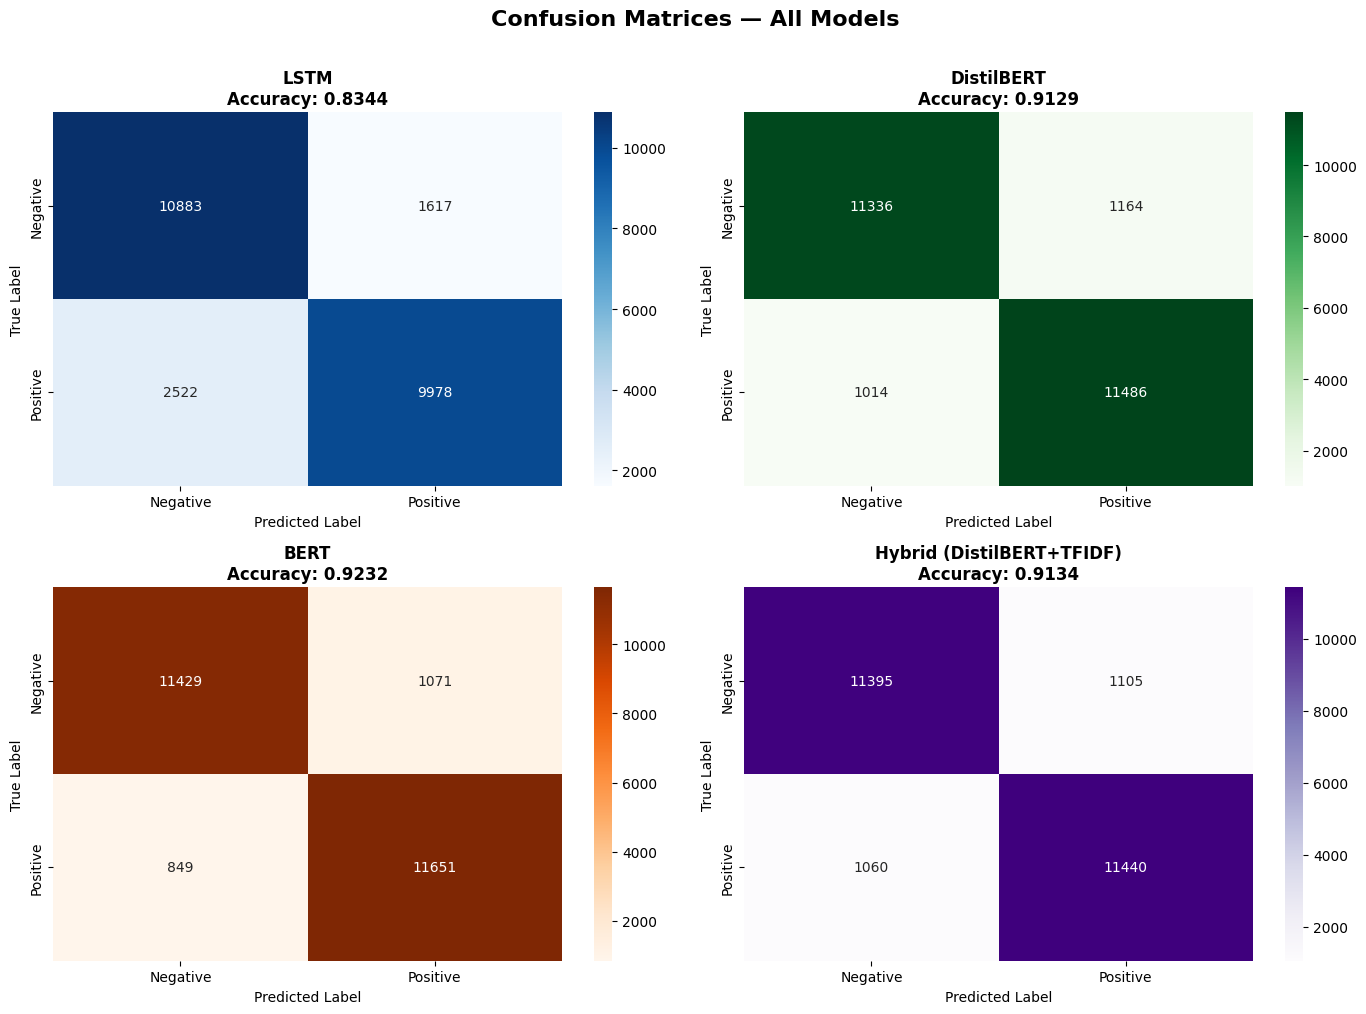

✅ Confusion matrices saved as confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)

colors = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (model_name, preds), cmap in zip(axes.flat, models.items(), colors):
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    acc = accuracy_score(test_labels, preds)
    ax.set_title(f'{model_name}\nAccuracy: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved as confusion_matrices.png')

## 📊 Section 11: Training & Validation Accuracy Curves

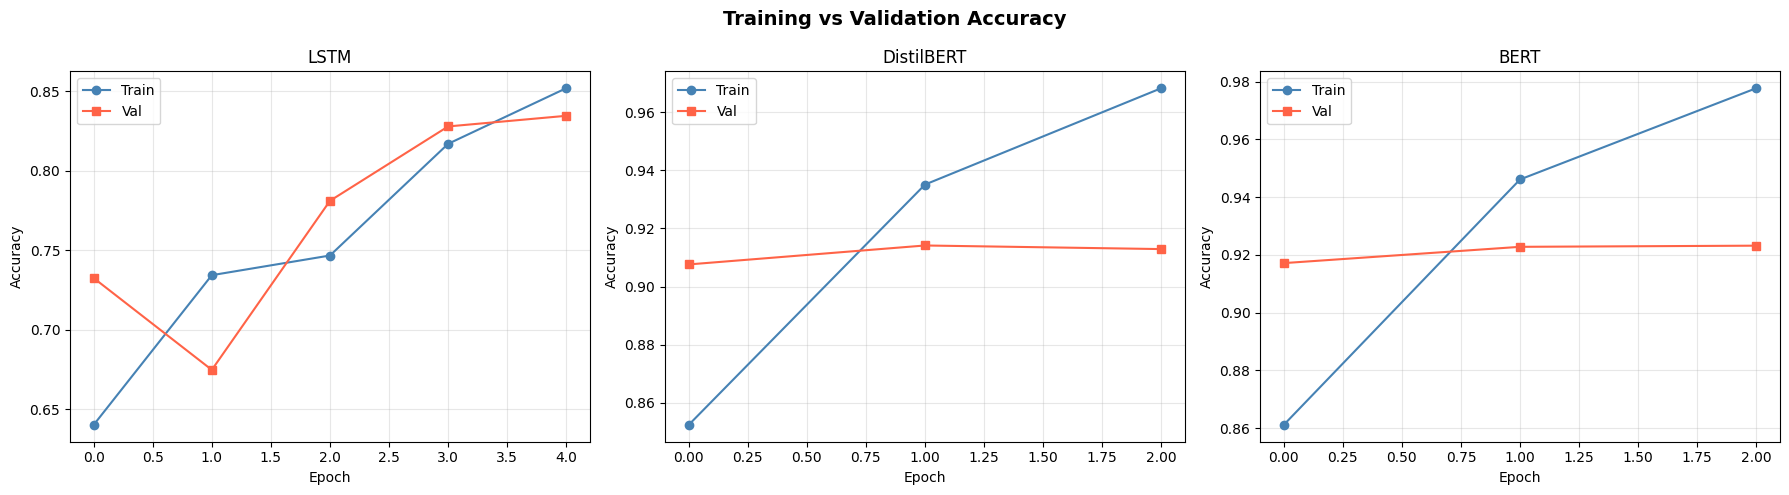

✅ Training curves saved as training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training vs Validation Accuracy', fontsize=14, fontweight='bold')

# LSTM
axes[0].plot(lstm_train_acc_history, label='Train', marker='o', color='steelblue')
axes[0].plot(lstm_val_acc_history,   label='Val',   marker='s', color='tomato')
axes[0].set_title('LSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DistilBERT
axes[1].plot(distilbert_train_hist, label='Train', marker='o', color='steelblue')
axes[1].plot(distilbert_val_hist,   label='Val',   marker='s', color='tomato')
axes[1].set_title('DistilBERT')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# BERT
axes[2].plot(bert_train_hist, label='Train', marker='o', color='steelblue')
axes[2].plot(bert_val_hist,   label='Val',   marker='s', color='tomato')
axes[2].set_title('BERT')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved as training_curves.png')

## 📊 Section 12: Model Accuracy Comparison Chart

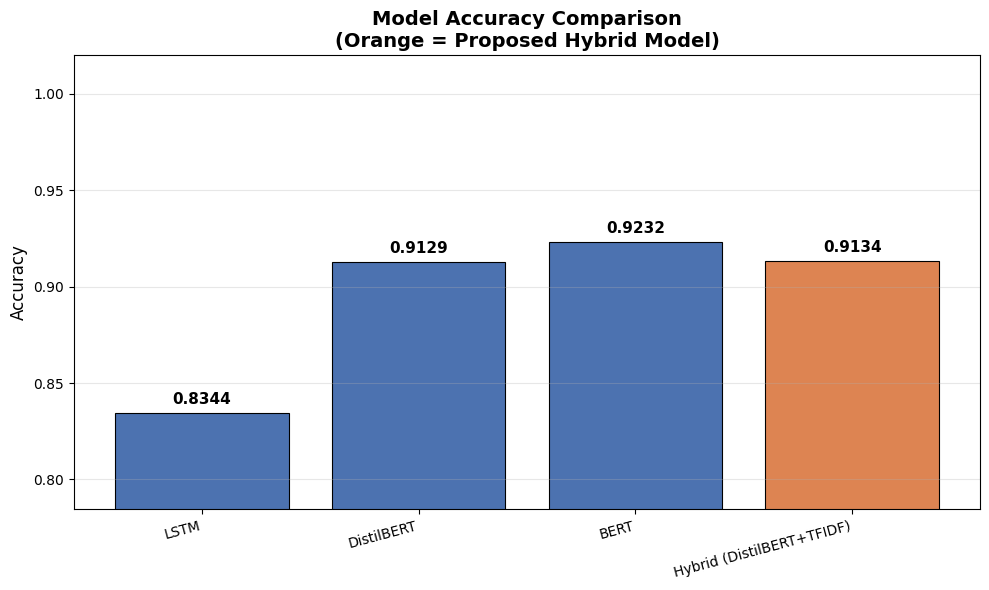

✅ Accuracy comparison chart saved as accuracy_comparison.png


In [ ]:
model_names = list(models.keys())
accuracies  = [accuracy_score(test_labels, p) for p in models.values()]

# Color the proposed model differently
bar_colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accuracies, color=bar_colors, edgecolor='black', linewidth=0.8)

# Annotate bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax.set_title('Model Accuracy Comparison\n(Orange = Proposed Hybrid Model)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(min(accuracies) - 0.05, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Accuracy comparison chart saved as accuracy_comparison.png')

## 📊 Section 13: Final Summary Table

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for model_name, preds in models.items():
    row = {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(test_labels, preds), 4),
        'Precision': round(precision_score(test_labels, preds, average='weighted'), 4),
        'Recall'   : round(recall_score(test_labels, preds, average='weighted'), 4),
        'F1 Score' : round(f1_score(test_labels, preds, average='weighted'), 4),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary_df.index += 1  # start rank from 1
summary_df.index.name = 'Rank'

print('\n===== FINAL MODEL PERFORMANCE SUMMARY =====')
print(summary_df.to_string())
summary_df.to_csv('model_summary.csv', index=True)
print('\n✅ Summary saved as model_summary.csv')


===== FINAL MODEL PERFORMANCE SUMMARY =====
                          Model  Accuracy  Precision  Recall  F1 Score
Rank                                                                  
1                          BERT    0.9232     0.9233  0.9232    0.9232
2     Hybrid (DistilBERT+TFIDF)    0.9134     0.9134  0.9134    0.9134
3                    DistilBERT    0.9129     0.9129  0.9129    0.9129
4                          LSTM    0.8344     0.8362  0.8344    0.8342

✅ Summary saved as model_summary.csv
